# Data exploration

Load raw Kraken tick CSVs for SOL, BCH, ADA, XRP. Check date ranges, row counts, and gaps per asset. This is where the history-length mismatch (SOL from 2021 vs the others from 2017/2018) should be confirmed visually before doing anything else.

In [1]:
import sys
sys.path.append('..')

import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import load_config
from src.data.loader import KrakenTickLoader

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
ASSET_PALETTE = dict(zip(["SOL", "BCH", "ADA", "XRP"], sns.color_palette("Set2", 4)))

config = load_config("../config/config.yaml")
config

{'assets': ['SOL', 'BCH', 'ADA', 'XRP'],
 'pairs': [['SOL', 'BCH'],
  ['SOL', 'ADA'],
  ['SOL', 'XRP'],
  ['BCH', 'ADA'],
  ['BCH', 'XRP'],
  ['ADA', 'XRP']],
 'data': {'raw_dir': 'data/raw',
  'processed_dir': 'data/processed',
  'target_bars': 2000},
 'alignment': {'method': 'calendar_join',
  'grid_freq': '1h',
  'common_start': None},
 'cointegration': {'test': 'engle_granger',
  'window_type': 'random',
  'n_windows': 50,
  'window_length_days': 30,
  'significance_level': 0.05,
  'random_seed': 42},
 'hedge_ratio': {'method': 'kalman'},
 'signal': {'lookback': 60, 'entry_z': 2.0, 'exit_z': 0.5},
 'backtest': {'cost_model': 'bps_per_side',
  'cost_bps': 5,
  'train_test_split': 'walk_forward',
  'out_of_sample_fraction': 0.3}}

In [2]:
asset_paths = {ticker: f"../data/raw/{ticker}.csv" for ticker in config["assets"]}
loader = KrakenTickLoader()
assets = loader.load_all(asset_paths)

SOL: 26,417,225 ticks | 2021-06-17 15:32:57 -> 2025-12-31 23:59:48


BCH: 9,395,447 ticks | 2017-08-01 16:01:37 -> 2025-12-31 23:53:58


ADA: 18,513,865 ticks | 2018-09-28 13:25:00 -> 2025-12-31 23:59:43


XRP: 30,957,309 ticks | 2017-05-18 15:46:56 -> 2025-12-31 23:59:57


## Tick-level summary

Row counts and date ranges per asset, and the very first ticks for each asset - Kraken listing-day prints are frequently noisy (illiquid order books, placeholder prices), which is worth flagging before it silently skews a dollar-bar threshold.

In [3]:
summary_rows = []
for ticker, df in assets.items():
    summary_rows.append({
        "asset": ticker,
        "n_ticks": df.height,
        "start": df["timestamp"].min(),
        "end": df["timestamp"].max(),
        "years_of_history": (df["timestamp"].max() - df["timestamp"].min()).days / 365.25,
        "min_price": df["price"].min(),
        "max_price": df["price"].max(),
    })
tick_summary = pl.DataFrame(summary_rows).sort("start")
tick_summary.write_csv("../outputs/tables/tick_summary.csv")
tick_summary

asset,n_ticks,start,end,years_of_history,min_price,max_price
str,i64,datetime[μs],datetime[μs],f64,f64,f64
"""XRP""",30957309,2017-05-18 15:46:56,2025-12-31 23:59:57,8.621492,0.1165,3.6645
"""BCH""",9395447,2017-08-01 16:01:37,2025-12-31 23:53:58,8.416153,73.6,600000.0
"""ADA""",18513865,2018-09-28 13:25:00,2025-12-31 23:59:43,7.258042,0.01854,3.09778
"""SOL""",26417225,2021-06-17 15:32:57,2025-12-31 23:59:48,4.539357,7.95,296.0


In [4]:
for ticker, df in assets.items():
    print(f"--- {ticker}: first 3 ticks ---")
    print(df.head(3))

--- SOL: first 3 ticks ---
shape: (3, 4)
┌────────────┬───────┬───────────┬─────────────────────┐
│ unixtime   ┆ price ┆ volume    ┆ timestamp           │
│ ---        ┆ ---   ┆ ---       ┆ ---                 │
│ i64        ┆ f64   ┆ f64       ┆ datetime[μs]        │
╞════════════╪═══════╪═══════════╪═════════════════════╡
│ 1623943977 ┆ 40.23 ┆ 15.453348 ┆ 2021-06-17 15:32:57 │
│ 1623943989 ┆ 40.23 ┆ 5.11519   ┆ 2021-06-17 15:33:09 │
│ 1623943993 ┆ 40.23 ┆ 0.3       ┆ 2021-06-17 15:33:13 │
└────────────┴───────┴───────────┴─────────────────────┘
--- BCH: first 3 ticks ---
shape: (3, 4)
┌────────────┬──────────┬─────────┬─────────────────────┐
│ unixtime   ┆ price    ┆ volume  ┆ timestamp           │
│ ---        ┆ ---      ┆ ---     ┆ ---                 │
│ i64        ┆ f64      ┆ f64     ┆ datetime[μs]        │
╞════════════╪══════════╪═════════╪═════════════════════╡
│ 1501603297 ┆ 600000.0 ┆ 0.00005 ┆ 2017-08-01 16:01:37 │
│ 1501603297 ┆ 3500.0   ┆ 0.001   ┆ 2017-08-01 16:01:37 │

**Data quality note:** BCH's first few ticks on 2017-08-01 include a print at \$600,000 against 0.00005 volume - a listing-day artifact, not a real trade at that price level, given BCH traded around \$400-700 within its first day. This is one reason the dollar-bar threshold is sized only *after* trimming to the common window and worth remembering if bar boundaries near an asset's listing date look strange.

## History coverage per asset

The chart below is the reason `trim_to_common_window` exists: SOL only has ticks from mid-2021, while BCH/ADA/XRP go back to 2017/2018. Any pairwise analysis has to respect SOL's start date as the binding constraint.

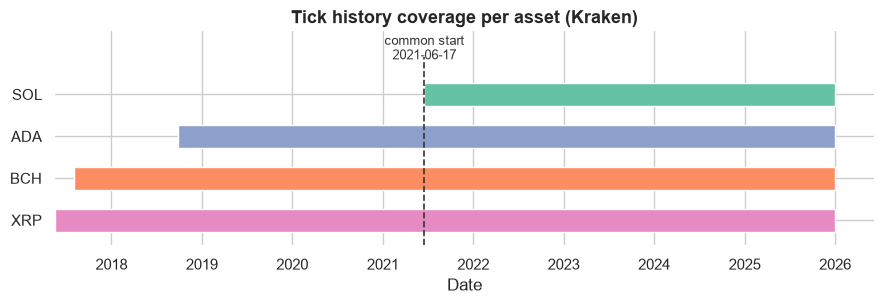

In [5]:
coverage = tick_summary.to_pandas()
fig, ax = plt.subplots(figsize=(9, 3.2))
for i, row in coverage.iterrows():
    ax.barh(row["asset"], (row["end"] - row["start"]).days, left=row["start"],
            color=ASSET_PALETTE[row["asset"]], height=0.55, edgecolor="white")
common_start = coverage["start"].max()
ax.axvline(common_start, color="0.2", linestyle="--", linewidth=1.2, ymax=0.88)
ax.annotate(
    f"common start\n{common_start.date()}",
    xy=(common_start, 3.75), ha="center", va="bottom", fontsize=9, color="0.2",
)
ax.set_ylim(-0.6, 4.5)
ax.set_xlabel("Date")
ax.set_title("Tick history coverage per asset (Kraken)", fontsize=13, fontweight="bold")
sns.despine(left=True, bottom=True)
fig.tight_layout()
fig.savefig("../outputs/figures/history_coverage.png", dpi=150)
plt.show()

## Daily price paths

Downsampled to daily median price (tick-level plotting at 30-90M rows/asset isn't meaningful visually). Log scale, since SOL/BCH trade in tens-hundreds of dollars and ADA/XRP trade well under \$5.

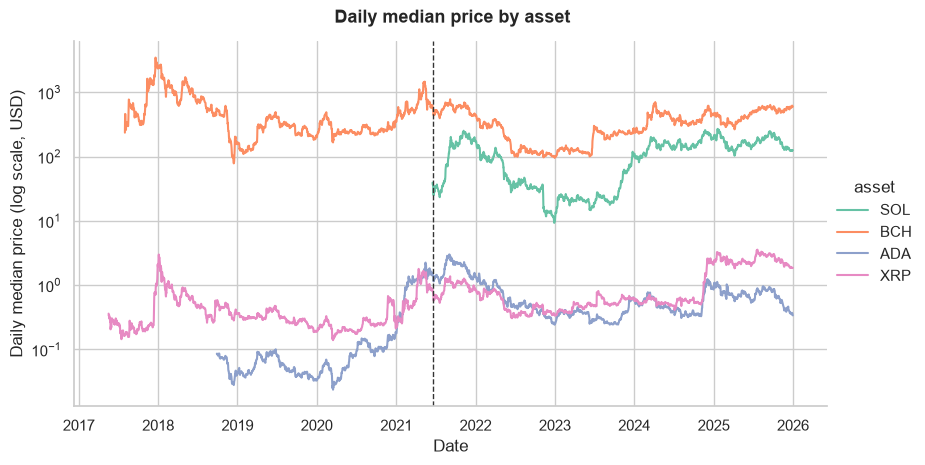

In [6]:
daily_frames = []
for ticker, df in assets.items():
    daily = (
        df.with_columns(pl.col("timestamp").dt.date().alias("date"))
        .group_by("date")
        .agg(pl.col("price").median().alias("price"))
        .sort("date")
        .with_columns(pl.lit(ticker).alias("asset"))
    )
    daily_frames.append(daily)
daily_prices = pl.concat(daily_frames).to_pandas()
daily_prices["date"] = pd.to_datetime(daily_prices["date"])

g = sns.relplot(
    data=daily_prices, x="date", y="price", hue="asset", kind="line",
    palette=ASSET_PALETTE, facet_kws=dict(despine=True), height=4.5, aspect=1.9,
)
g.set(yscale="log")
g.ax.axvline(pd.Timestamp(common_start), color="0.2", linestyle="--", linewidth=1)
g.set_axis_labels("Date", "Daily median price (log scale, USD)")
g.figure.suptitle("Daily median price by asset", fontsize=13, fontweight="bold", y=1.03)
g.savefig("../outputs/figures/daily_price_paths.png", dpi=150)

## Return correlation structure (common window only)

A first look at co-movement across the four assets, restricted to the window where all four actually have data (post SOL-listing), using daily log returns.

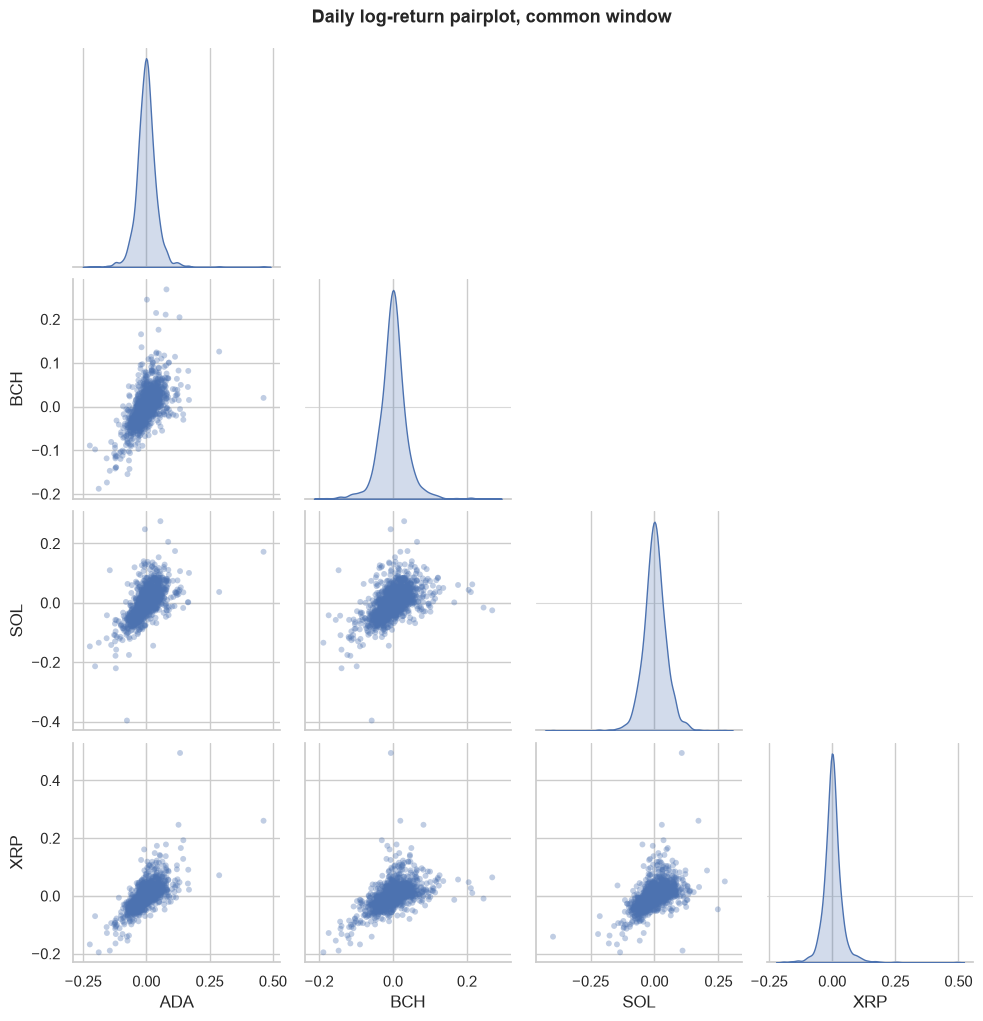

In [7]:
common_daily = daily_prices[daily_prices["date"] >= pd.Timestamp(common_start)]
wide = common_daily.pivot(index="date", columns="asset", values="price").sort_index()
log_returns = wide.apply(lambda s: pd.Series(s).pipe(lambda x: (x / x.shift(1)).apply('log')))
log_returns = log_returns.dropna()

pg = sns.pairplot(
    log_returns, diag_kind="kde", plot_kws=dict(alpha=0.35, s=18, edgecolor="none"),
    corner=True,
)
for ax in pg.axes.flatten():
    if ax is not None:
        ax.axhline(0, color="0.85", linewidth=0.8, zorder=0)
        ax.axvline(0, color="0.85", linewidth=0.8, zorder=0)
pg.figure.suptitle("Daily log-return pairplot, common window", y=1.02, fontsize=13, fontweight="bold")
pg.savefig("../outputs/figures/daily_return_pairplot.png", dpi=150)

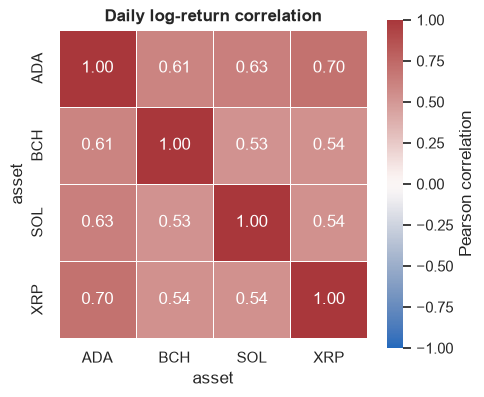

In [8]:
corr = log_returns.corr()
fig, ax = plt.subplots(figsize=(5, 4.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Daily log-return correlation", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("../outputs/figures/daily_return_correlation.png", dpi=150)
plt.show()

## Takeaways

- SOL's tick history starts 2021-06-17; BCH/ADA/XRP have several more years of history before that. `trim_to_common_window` (implemented in `src/data/bars.py`) enforces SOL's start as the shared floor before any dollar-bar sizing happens.
- Raw return correlations are all positive and moderate-to-high (typical of major-cap crypto beta to the broader market) - correlation alone doesn't imply a tradeable cointegrating relationship, which is exactly why the next steps run an explicit Engle-Granger scan rather than trading off correlation.
- A few listing-day ticks contain clearly stale/placeholder prices; the dollar-bar aggregation naturally dilutes their influence, but it is worth remembering when a specific bar looks like an outlier.